In [1]:
from pathlib import Path
current_dir = Path().resolve()
from microlive.imports import *
from microlive import microscopy as mi
main_dir = Path().resolve().parent


In [2]:
def plot_multiple_frames_horizontally(image, frame_indexes, x_labels, 
                                      use_gaussian_filter=False, 
                                      min_percentile=0.5, 
                                      max_percentile=99.5, 
                                      use_max_projection=False, 
                                      cmap='Spectral', 
                                      figsize=(18, 6), 
                                      save_plots=False,
                                      plot_name='temp.png', 
                                      microns_per_pixel=None,
                                      show_plot=True,
                                      # New zoom parameters:
                                      show_zoom_in=False, 
                                      zoom_coords=None,    # tuple (x, y) in pixels
                                      zoom_size=50,        # size (in pixels) of the zoom square
                                      zoom_inset_fraction="25%"):  # size of inset relative to subplot
    """
    Plots multiple subplots horizontally, one for each frame specified in frame_indexes.
    
    Parameters:
      image : numpy array
          The image array in one of two formats:
            - 4D: [Z, Y, X, C]
            - 5D: [T, Z, X, Y, C]
      frame_indexes : list of int
          List of frame indexes to plot. If image is 5D, these refer to the T dimension.
      x_labels : list of str
          List of labels to assign as the x-axis label for each subplot.
      use_gaussian_filter : bool, optional
          If True, apply a Gaussian filter (sigma=0.3) to the processed image.
      min_percentile : float, optional
          The lower percentile for normalization.
      max_percentile : float, optional
          The upper percentile for normalization.
      use_max_projection : bool, optional
          If True, compute a maximum projection along the Z axis; otherwise, use the central Z-slice.
      cmap : str or matplotlib colormap, optional
          The colormap to use when displaying the image.
      figsize : tuple, optional
          Figure size (width, height) for the overall plot.
      save_plots : bool, optional
          If True, save the figure to file using plot_name.
      plot_name : str, optional
          The filename for saving the plot.
      microns_per_pixel : float, optional
          The physical size of one pixel in microns. If provided, a scalebar is added.
      show_plot : bool, optional
          If True, display the plot; otherwise, close it.
      show_zoom_in : bool, optional
          If True, draw a zoom-in rectangle and add an inset showing the zoomed crop.
      zoom_coords : tuple (x, y), optional
          Coordinates (in pixels) of the top-left corner of the zoom-in crop.
      zoom_size : int, optional
          Size (in pixels) of the square zoom-in crop.
      zoom_inset_fraction : str, optional
          Size of the inset axes (e.g. "25%") relative to the subplot.
    """
    plt.rcdefaults()
    
    # Determine image format and extract a list of 4D images with shape [Z, Y, X, C]
    if image.ndim == 5:
        # Format: [T, Z, X, Y, C]
        images_to_plot = []
        for t in frame_indexes:
            img_t = image[t, ...]
            # Reorder axes from [Z, X, Y, C] to [Z, Y, X, C]
            img_t = np.transpose(img_t, (0, 2, 1, 3))
            images_to_plot.append(img_t)
    elif image.ndim == 4:
        images_to_plot = [image[i, ...] for i in frame_indexes if i < image.shape[0]]
    else:
        raise ValueError("Image must be either 4D ([Z, Y, X, C]) or 5D ([T, Z, X, Y, C]).")
    
    # Process each 4D image to produce a 2D image for plotting.
    processed_images = []
    for img in images_to_plot:
        if use_max_projection:
            proj = np.max(img, axis=0)
        else:
            center_slice = img.shape[0] // 2
            proj = img[center_slice, ...]
        # If multiple channels, take the first channel for display.
        if proj.shape[-1] > 1:
            proj = proj[..., 0]
        lower = np.percentile(proj, min_percentile)
        upper = np.percentile(proj, max_percentile)
        proj_clipped = np.clip(proj, lower, upper)
        if use_gaussian_filter:
            proj_clipped = gaussian_filter(proj_clipped, sigma=0.5)
        norm_img = (proj_clipped - lower) / (upper - lower + 1e-8)
        processed_images.append(norm_img)
    
    n_plots = len(processed_images)
    fig, axes = plt.subplots(1, n_plots, figsize=figsize)
    if n_plots == 1:
        axes = [axes]
    
    # Define font properties for scalebar (without text, color is set by the ScaleBar's color argument)
    font_props = {'size': 0, }
    
    for ax, img, label in zip(axes, processed_images, x_labels):
        ax.imshow(img, cmap=cmap, vmin=0, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_xlabel(label, fontsize=12)
        if microns_per_pixel is not None:
            scalebar = ScaleBar(dx=microns_per_pixel, units='um', length_fraction=0.25,
                                location='lower right', box_color='k', color='w',
                                font_properties=font_props, label='')
            ax.add_artist(scalebar)
        
        # If zoom-in is enabled and zoom_coords is provided, add a rectangle and an inset.
        if show_zoom_in and (zoom_coords is not None):
            x0, y0 = zoom_coords
            # Ensure indices are within image dimensions.
            y0 = int(np.clip(y0, 0, img.shape[0] - zoom_size))
            x0 = int(np.clip(x0, 0, img.shape[1] - zoom_size))
            # Draw rectangle on the main image
            rect = plt.Rectangle((x0, y0), zoom_size, zoom_size, edgecolor='w', facecolor='none', linewidth=1)
            ax.add_patch(rect)
            # Create inset axes at the top right of the current subplot.
            inset_ax = inset_axes(ax, width=zoom_inset_fraction, height=zoom_inset_fraction, loc='upper right', borderpad=1)
            zoom_crop = img[y0:y0+zoom_size, x0:x0+zoom_size]
            inset_ax.imshow(zoom_crop, cmap=cmap, vmin=0, vmax=1)
            # make red the inset rectangle
            inset_ax.add_patch(plt.Rectangle((0, 0), zoom_size-1, zoom_size-1, edgecolor='w', facecolor='none', linewidth=2))
            inset_ax.set_xticks([])
            inset_ax.set_yticks([])
    
    plt.tight_layout()
    
    plt.subplots_adjust(wspace=0.04, hspace=0)  # Reduce spacing between images

    if save_plots:
        plt.savefig(plot_name, bbox_inches='tight', dpi=300)
    if show_plot:
        plt.show()
    else:
        plt.close()
    return fig, axes

In [ ]:
#processed_data = 'utag'
#processed_data = 'suntag'
processed_data = 'alfatag'
#processed_data = 'utag_c_free'

if processed_data == 'utag':
    plot_name = 'UTag'
    lif_dir = Path('/Users/nzlab-la/Library/CloudStorage/OneDrive-TheUniversityofColoradoDenver/General - Zhao (NZ) Lab/Zhao lab shared folder/Our papers/Anti-Utag-frankenbody paper/Translation/Utag_JY/20250205_pNZ208_335_MCP-CAAX.lif')
    list_images, list_names, pixel_xy_um, voxel_z_um, channel_names, number_color_channels,list_time_intervals, bit_depth  = mi.ReadLif(lif_dir,show_metadata=False,save_tif=False,save_png=False,format='TZYXC').read()
    selected_image = list_images[3] # 3 is the index of the image with the best focus
    max_percentile=99.9
    min_percentile=10

elif processed_data == 'suntag':
    plot_name = 'SunTag'
    lif_dir = Path('/Users/nzlab-la/Library/CloudStorage/OneDrive-TheUniversityofColoradoDenver/General - Zhao (NZ) Lab/Zhao lab shared folder/Our papers/Anti-Utag-frankenbody paper/Translation/Suntag_JY/20250131_pNZ266_317_MCP-CAAX.lif')
    list_images, list_names, pixel_xy_um, voxel_z_um, channel_names, number_color_channels,list_time_intervals, bit_depth  = mi.ReadLif(lif_dir,show_metadata=False,save_tif=False,save_png=False,format='TZYXC').read()
    selected_image = list_images[6] # 3 is the index of the image with the best focus
    max_percentile=99.95
    min_percentile=20

elif processed_data == 'alfatag':
    plot_name = 'AlfaTag'
    lif_dir = Path('/Users/nzlab-la/Library/CloudStorage/OneDrive-TheUniversityofColoradoDenver/General - Zhao (NZ) Lab/Zhao lab shared folder/Our papers/Anti-Utag-frankenbody paper/Translation/ALFAtag_JY/20250214_pNZ267_pJY016_CAAX.lif')
    list_images, list_names, pixel_xy_um, voxel_z_um, channel_names, number_color_channels,list_time_intervals, bit_depth  = mi.ReadLif(lif_dir,show_metadata=False,save_tif=False,save_png=False,format='TZYXC').read()
    selected_image = list_images[14] # 3 is the index of the image with the best focus
    max_percentile=99.95
    min_percentile=25

elif processed_data == 'utag_c_free':
    plot_name = 'UTag cysteine free'
    lif_dir = Path('/Users/nzlab-la/Library/CloudStorage/OneDrive-TheUniversityofColoradoDenver/General - Zhao (NZ) Lab/Zhao lab shared folder/Our papers/Anti-Utag-frankenbody paper/Translation/UTag_CRemoved_JY/20250214_pNZ208_377_CAAX.lif')
    list_images, list_names, pixel_xy_um, voxel_z_um, channel_names, number_color_channels,list_time_intervals, bit_depth  = mi.ReadLif(lif_dir,show_metadata=False,save_tif=False,save_png=False,format='TZYXC').read()
    selected_image = list_images[2] # 3 is the index of the image with the best focus
    max_percentile=99.9
    min_percentile=10



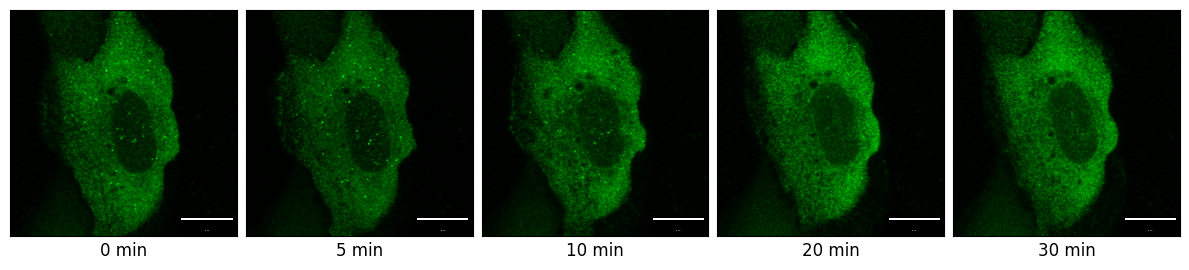

(<Figure size 1200x600 with 5 Axes>,
 array([<Axes: xlabel='0 min'>, <Axes: xlabel='5 min'>,
        <Axes: xlabel='10 min'>, <Axes: xlabel='20 min'>,
        <Axes: xlabel='30 min'>], dtype=object))

In [ ]:
#selected_image = list_images[14] # 3 is the index of the image with the best focus

plot_multiple_frames_horizontally(selected_image,
                                  frame_indexes=[0, 4, 9, 19, 29],
                                  x_labels=['0 min','5 min','10 min', '20 min','30 min'],
                                  use_gaussian_filter=True,
                                  min_percentile=min_percentile,
                                  max_percentile=max_percentile,
                                  use_max_projection=True,
                                  cmap=cmap_list_imagej[0], 
                                  figsize=(12, 6),
                                  save_plots=False,
                                  plot_name='temp.png',
                                  microns_per_pixel=pixel_xy_um,
                                  show_plot=True,
                                  show_zoom_in=False,
                                  zoom_coords=(250, 350),  # x, y coordinates for the zoom crop
                                  zoom_size=70,
                                  zoom_inset_fraction="30%")